In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Шум Гаусса + постоянный шум

In [3]:
image = cv2.imread("images/sar_1.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [4]:
mean = 0
stddev = 255
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  40,   0, ..., 255,   0, 203],
       [  3, 255, 174, ...,   0, 255,   0],
       [  0,   0, 131, ...,   0,   0, 255],
       ...,
       [  0,   0, 100, ..., 255,   0,  37],
       [  0,  87,   0, ...,   0,  14, 255],
       [255, 255,   0, ...,  54,   0, 255]],
      shape=(675, 1200), dtype=uint8)

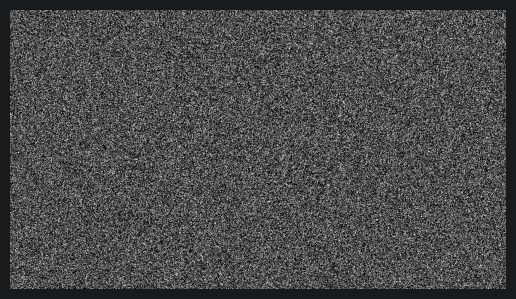

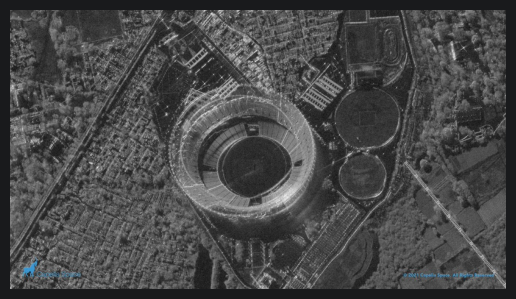

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

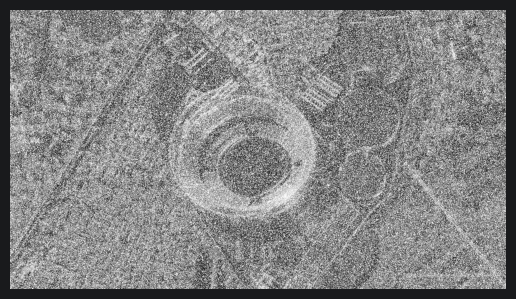

In [5]:
plt.imshow(noise_gauss, cmap="gray")
plt.axis("off")
plt.show()

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.axis("off")
plt.show()

noisy_image = cv2.add(image_gray, noise_gauss)# складываем исходное изображение с шумом
plt.imshow(noisy_image, cmap="gray")
plt.axis("off")

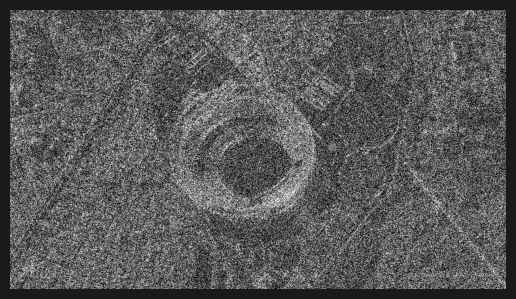

In [9]:
noise_uniform_cv = np.zeros(image_gray.shape, dtype=np.float32)
cv2.randu(noise_uniform_cv, -200.0, 200.0)

noisy_uniform_cv = image_gray.astype(np.float32) + noise_uniform_cv
noisy_uniform_cv = np.clip(noisy_uniform_cv, 0, 255).astype(np.uint8)


plt.imshow(noisy_uniform_cv, cmap='gray')
plt.axis('off')
plt.show()

# Тестирование фильтров

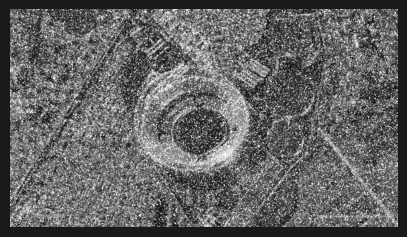

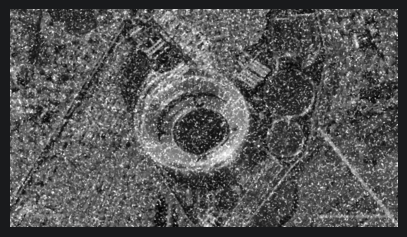

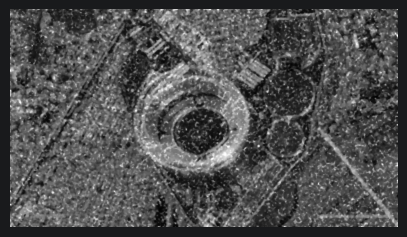

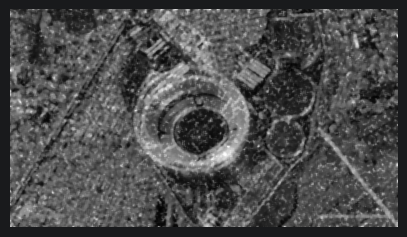

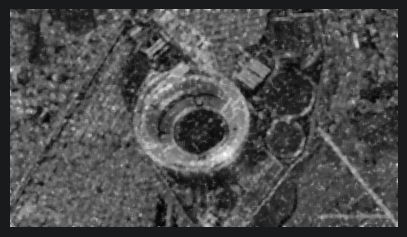

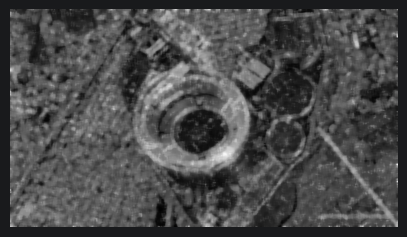

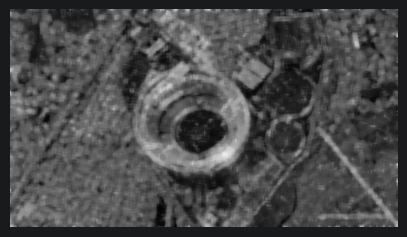

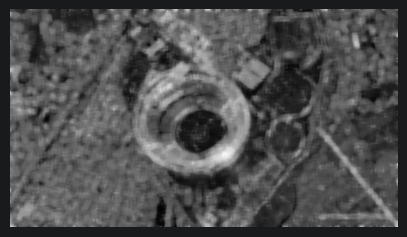

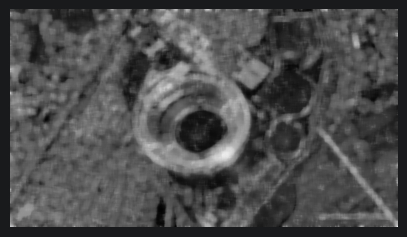

In [36]:
ksize = np.arange(3, 20, 2)
for k in ksize:
    image_gray_median = cv2.medianBlur(noisy_image, k)
    plt.figure(figsize=(5, 5))
    plt.imshow(image_gray_median, cmap="gray")
    plt.axis("off")
    plt.show()